# Ablation Significance Analysis

Checks the three ablation studies (`ablations/ablation1_model_comparison.py`,
`ablation2_curve_preprocessing.py`, `ablation3_generalisability.py`) for statistically
significant differences between conditions, reusing the exact same Friedman + pairwise
Wilcoxon (Holm-Bonferroni corrected) / McNemar framework as `08_statistical_comparison.py`
-- no test logic is reimplemented here, just adapted to the ablation scripts' flat
per-dataset `*_performances.joblib` schema (same per-model keys as
`classification_performances.joblib`, just one dataset's results per file instead of
nested under `{dataset_name: {mode: {...}}}`).

**Primary test (N >= 2 datasets):** Friedman test across datasets (one mean-accuracy
value per dataset per condition -> independent observations), then pairwise Wilcoxon
signed-rank with Holm-Bonferroni correction, effect size = rank-biserial correlation.

**Fallback (N = 1 dataset):** McNemar's test on concatenated per-sample outcomes.


In [1]:
import os, sys, importlib.util
import joblib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Run from the notebook's own directory's parent (main/), matching house style.
try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config

# 08_statistical_comparison.py can't be `import`ed (starts with a digit) -- load it as
# a module directly. exec_module runs it with __name__ != '__main__', so the CLI/argparse
# block at the bottom does not execute; only the reusable functions/constants do.
_spec = importlib.util.spec_from_file_location(
    "stat_comparison", str(Path.cwd() / "08_statistical_comparison.py"))
stat_comparison = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(stat_comparison)

# stat_comparison imports matplotlib and calls matplotlib.use("Agg") at module load --
# re-assert the inline backend afterwards so figures render in this notebook.
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
from IPython.display import HTML, display

# Same 5 LAB_DDM_paper folders the user's ablation-1/3 SLURM array jobs target
# (01, 02, 03, 09, 10 -- see abl_ablation1_model_comparison.sh / abl_ablation3_generalisability.sh).
LAB_DATASETS = ['01_ACA_qdPCR', '02_AMCA_qdLAMP', '03_AMCA_qdPCR']

# Mirrors each ablation script's MODELS list exactly -- keep these in sync if the
# scripts' lists change.
ABLATION1_MODELS = ['knn', 'cnn', 'gru', 'transformer', 'cnn_gru_dual', 'cnn_gru_dual_attn_recon']
ABLATION3_CGD_FAMILY = ['cnn_gru_dual', 'cnn_gru_dual_mtl', 'gru_rcfd_cgd', 'cnn_gru_dual_supcon3']
ABLATION3_ATTN_FAMILY = ['cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_mtl',
                         'gru_rcfd_attn_recon', 'cnn_gru_dual_attn_recon_supcon3']

ALPHA = 0.05
METRIC = 'accuracy'

def show_result(stats, figs, test_type, metric_name='Accuracy', alpha=ALPHA, title=None):
    """Render one comparison's summary table + figures inline, reusing
    stat_comparison's HTML/plot builders untouched."""
    if title:
        display(HTML(f'<h3>{title}</h3>'))
    if not stats or 'error' in (stats or {}):
        display(HTML(f'<p style="color:#e74c3c">{(stats or {}).get("error", "No data.")}</p>'))
        return
    html = stat_comparison.build_tab_content(stats, figs, test_type, metric_name, alpha)
    display(HTML(html))
    for fig in figs.values():
        display(fig)
        plt.close(fig)


In [3]:
def load_ablation_exp_data(joblib_path, models, curve_type='ori_curve', metric=METRIC):
    """Adapt one ablation *_performances.joblib (flat {filter: {...}} schema --
    same per-model y_preds_AC_*_/y_trues_ keys as classification_performances.joblib,
    just one dataset's results, not nested under {dataset_name: {mode: {...}}}) into
    the {curve_type: {filter: {model: {fold_metrics, mean_metric, y_true_all,
    y_pred_all, n_folds}}}} shape stat_comparison.build_accuracy_matrix/_get_value
    expect. Mirrors stat_comparison.load_exp_data's inner loop exactly."""
    joblib_path = Path(joblib_path)
    if not joblib_path.exists():
        return None
    raw = joblib.load(joblib_path)

    out_filters = {}
    for filter_key, filter_results in raw.items():
        if "y_trues_" not in filter_results:
            continue
        y_trues_ = filter_results["y_trues_"]
        n_folds = len(y_trues_)
        if n_folds == 0:
            continue

        out_filters[filter_key] = {}
        for model_key in models:
            preds_key = config.MODEL_KEY_MAP[model_key][0]
            if preds_key not in filter_results:
                continue
            y_preds_ = filter_results[preds_key]
            if len(y_preds_) != n_folds:
                continue

            fold_metrics, y_true_parts, y_pred_parts = [], [], []
            for fi in range(n_folds):
                y_true = np.asarray(y_trues_[fi])
                y_pred = np.asarray(y_preds_[fi])
                if len(y_true) == 0 or len(y_true) != len(y_pred):
                    continue
                fold_metrics.append(stat_comparison._compute_metric(y_true, y_pred, metric))
                y_true_parts.append(y_true)
                y_pred_parts.append(y_pred)

            if not fold_metrics:
                continue
            out_filters[filter_key][model_key] = {
                "fold_metrics": fold_metrics,
                "mean_metric":  float(np.mean(fold_metrics)),
                "y_true_all":   np.concatenate(y_true_parts),
                "y_pred_all":   np.concatenate(y_pred_parts),
                "n_folds":      len(fold_metrics),
            }
    return {curve_type: out_filters}


def load_ablation_across_datasets(exp_folder, dataset_names, joblib_name, models,
                                  curve_type='ori_curve', metric=METRIC):
    """One (name, exp_data) pair per dataset with usable results -- the shape
    stat_comparison.run_comparison's exp_data_list expects (one entry per
    independent 'experiment' for the Friedman test)."""
    exp_data_list = []
    for name in dataset_names:
        path = Path(exp_folder) / name / "ablations" / joblib_name
        data = load_ablation_exp_data(path, models, curve_type=curve_type, metric=metric)
        if data is not None and any(data[curve_type].values()):
            exp_data_list.append((name, data))
        else:
            print(f'  [WARN] no usable results for {name} at {path}')
    return exp_data_list


## Ablation 1 -- Model Comparison

kNN vs CNN vs GRU vs Transformer vs cnn_gru_dual vs cnn_gru_dual_attn_recon, across the 5 LAB_DDM_paper datasets. `cnn_gru_dual_attn_recon` is soft-skipped on LAB data (no pixel-grid metadata) -- if it has zero results across all 5 datasets it's automatically dropped from the comparison by `build_accuracy_matrix` (conditions with any missing data are excluded).

  [WARN] Dropping 1 conditions with missing data in ≥1 folder.


Rank,Condition,Mean Accuracy (%),Friedman Avg Rank,vs Baseline (adj. p),Effect size (r)
1,★ CNN+GRU Dual,96.58 ± 2.88%,1.00,— (baseline),—
2,GRU (ACA),95.67 ± 3.49%,2.33,1.000,-1.000
3,Trans (ACA),93.60 ± 3.50%,3.67,1.000,-1.000
4,KNN (ACA),92.25 ± 6.65%,3.67,1.000,-1.000
5,CNN (ACA),91.86 ± 7.08%,4.33,1.000,-1.000

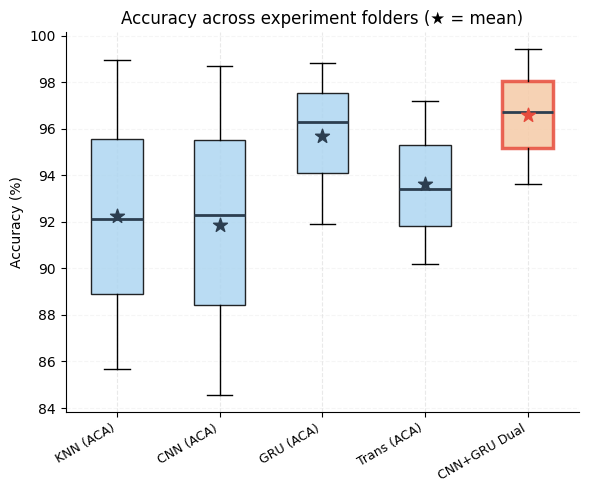
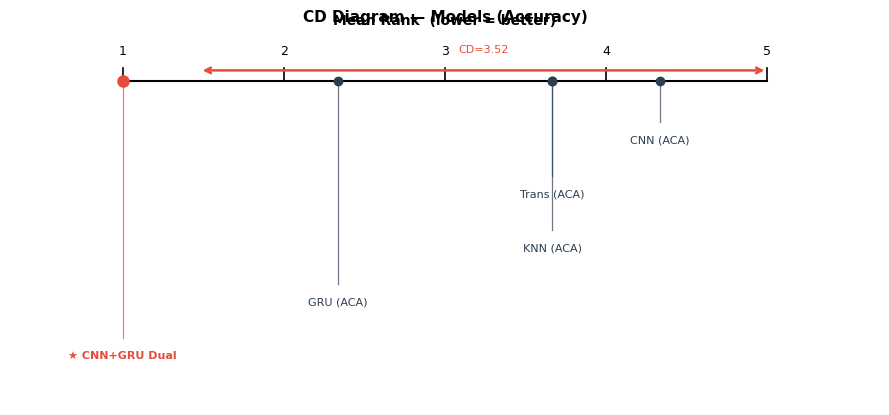
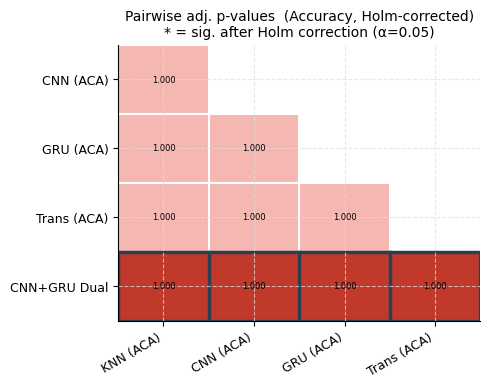

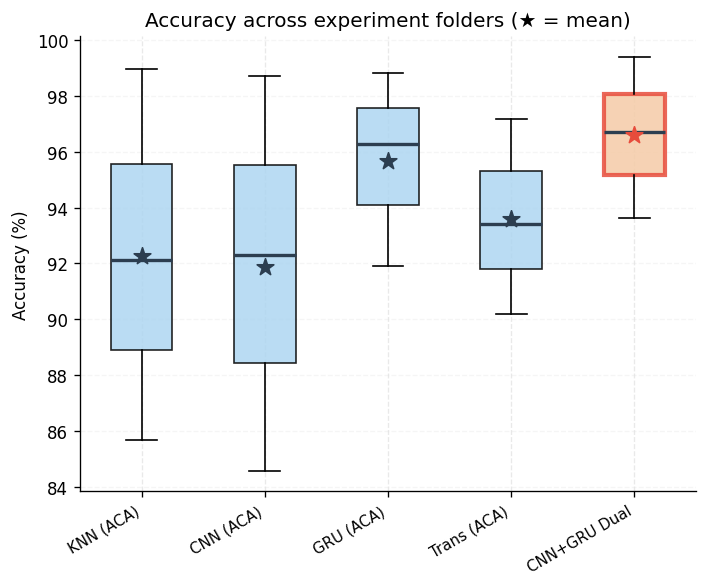

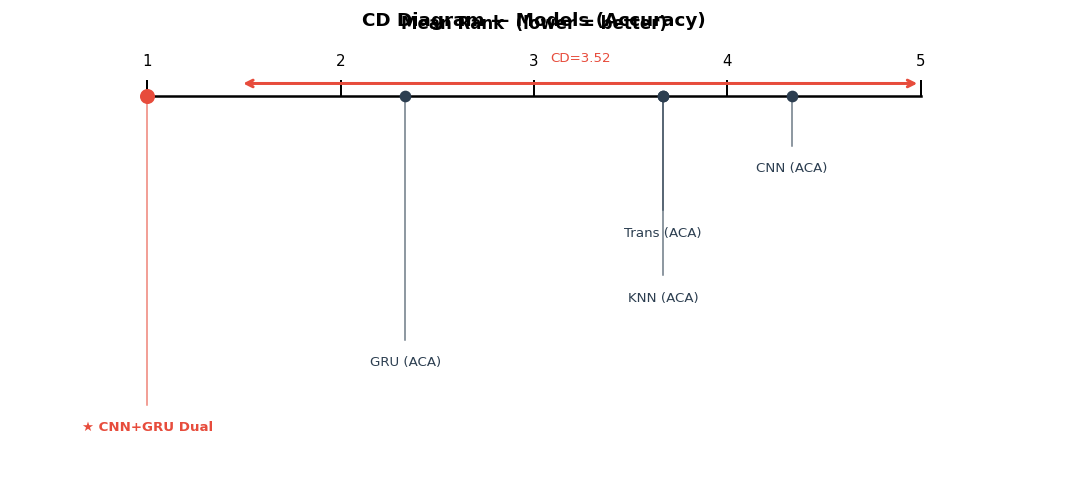

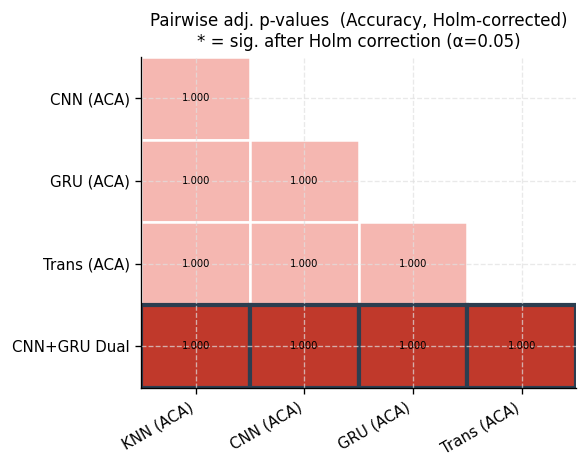

In [4]:
exp_data_1 = load_ablation_across_datasets(
    config.LAB_EXP_FOLDER, LAB_DATASETS,
    "ablation1_model_comparison_performances.joblib", ABLATION1_MODELS)

stats1, figs1, test_type1, _ = stat_comparison.run_comparison(
    exp_data_1,
    compare_axis="models",
    all_conditions=ABLATION1_MODELS,
    condition_print_map=config.MODEL_PRINT_MAP,
    fixed={"curve_type": "ori_curve", "filter": None},
    baseline_key="cnn_gru_dual",
    metric=METRIC,
    alpha=ALPHA,
)
show_result(stats1, figs1, test_type1, title="Ablation 1: Model Comparison")


In [13]:
config.MODEL_PRINT_MAP

{'cnn': 'CNN (ACA)',
 'lstm': 'LSTM (ACA)',
 'gru': 'GRU (ACA)',
 'rnn': 'RNN (ACA)',
 'transformer': 'Trans (ACA)',
 'rf': 'RF (ACA)',
 'knn': 'KNN (ACA)',
 'ffi': 'LR (FFI)',
 'cnn_lf': 'CNN LF',
 'lstm_lf': 'LSTM LF',
 'trans_lf': 'Trans LF',
 'gru_lf': 'GRU LF',
 'cnn_gru_dual': 'CNN+GRU Dual',
 'cnn_trans_dual': 'CNN+Tr Dual',
 'cnn_lstm_dual': 'CNN+LSTM Dual',
 'lstm_ae_clf': 'LSTM-AE Clf',
 'cnn_gru_gate': 'CNN+GRU Gate',
 'cnn_gru_hadamard': 'CNN+GRU Hadamard',
 'cnn_gru_crossattn': 'CNN+GRU CoAttn',
 'cnn_gru_film': 'CNN+GRU FiLM',
 'cnn_trans_gate': 'CNN+Tr Gate',
 'cnn_trans_hadamard': 'CNN+Tr Hadamard',
 'cnn_trans_crossattn': 'CNN+Tr CoAttn',
 'cnn_trans_film': 'CNN+Tr FiLM',
 'gnn_gat': 'GNN (GAT)',
 'gnn_gcn': 'GNN (GCN)',
 'cnn_gru_dual_cosine_recon': 'CNN+GRU CosRecon',
 'cnn_gru_dual_attn_recon': 'CNN+GRU AttnRecon',
 'cnn_mtl': 'CNN MTL',
 'lstm_mtl': 'LSTM MTL',
 'gru_mtl': 'GRU MTL',
 'rnn_mtl': 'RNN MTL',
 'transformer_mtl': 'Trans MTL',
 'cnn_gru_dual_mtl': 'CNN+

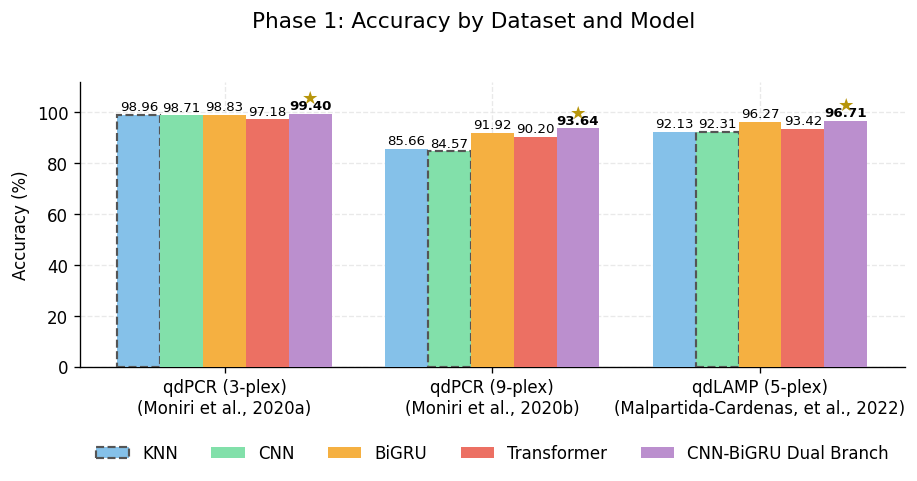

In [17]:
DATASET_LABELS_1 = {
    '01_ACA_qdPCR':   'qdPCR (3-plex)\n(Moniri et al., 2020a)',
    '03_AMCA_qdPCR':  'qdPCR (9-plex)\n(Moniri et al., 2020b)',
    '02_AMCA_qdLAMP': 'qdLAMP (5-plex)\n(Malpartida-Cardenas, et al., 2022)',
}
DATASET_ORDER_1 = ['01_ACA_qdPCR', '03_AMCA_qdPCR', '02_AMCA_qdLAMP']
BASELINE_MODELS_1 = {'01_ACA_qdPCR': 'knn', '03_AMCA_qdPCR': 'cnn', '02_AMCA_qdLAMP': 'cnn'}

MODEL_COLORS_1 = {
    'knn':                     '#85C1E9',
    'cnn':                     '#82E0AA',
    'gru':                     '#F5B041',
    'transformer':             '#EC7063',
    'cnn_gru_dual':            '#BB8FCE',
    'cnn_gru_dual_attn_recon': '#F7DC6F',
}

MODEL_PRINT_MAP = {
    'knn':                     'KNN',
    'cnn':                     'CNN',
    'gru':                     'BiGRU',
    'transformer':             'Transformer',
    'cnn_gru_dual':            'CNN-BiGRU Dual Branch',
    'cnn_gru_dual_attn_recon': 'CNN-BiGRU Dual + Attn Recon',
}

def plot_ablation1_barchart(exp_data, models, baseline_map, model_colors, dataset_order=None,
                            dataset_labels=None, curve_type='ori_curve', filter_key=None):
    data_by_name = dict(exp_data)
    dataset_names = [n for n in (dataset_order or data_by_name) if n in data_by_name]
    present_models = [m for m in models
                       if any(m in data_by_name[n][curve_type].get(filter_key, {}) for n in dataset_names)]

    acc = np.full((len(dataset_names), len(present_models)), np.nan)
    for i, name in enumerate(dataset_names):
        entry = data_by_name[name][curve_type].get(filter_key, {})
        for j, m in enumerate(present_models):
            if m in entry:
                acc[i, j] = entry[m]['mean_metric'] * 100
    best_j = np.nanargmax(acc, axis=1)

    n_models = len(present_models)
    width = 0.8 / n_models
    x = np.arange(len(dataset_names))

    fig, ax = plt.subplots(figsize=(2 * len(dataset_names) + 2, 4))
    for j, m in enumerate(present_models):
        offsets = x + (j - (n_models - 1) / 2) * width
        bars = ax.bar(offsets, acc[:, j], width=width, color=model_colors.get(m, '#95A5A6'),
                      label=MODEL_PRINT_MAP.get(m, m), zorder=3)
        for i, bar in enumerate(bars):
            v = acc[i, j]
            if np.isnan(v):
                continue
            is_baseline = baseline_map.get(dataset_names[i]) == m
            is_best = j == best_j[i]
            if is_baseline:
                bar.set_linestyle('--')
                bar.set_edgecolor('#555555')
                bar.set_linewidth(1.3)
            if is_best:
                ax.text(bar.get_x() + bar.get_width() / 2, v + 2.6, '\u2605',
                        ha='center', va='bottom', fontsize=11, color='#B7950B', zorder=4)
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.6, f'{v:.2f}',
                    ha='center', va='bottom', fontsize=8,
                    fontweight='bold' if is_best else 'normal')

    ax.set_xticks(x)
    ax.set_xticklabels([(dataset_labels or {}).get(n, n) for n in dataset_names])
    # ax.set_xlabel('Dataset')
    ax.set_ylabel('Accuracy (%)')
    ax.set_ylim(0, 112)
    fig.suptitle('Phase 1: Accuracy by Dataset and Model', fontsize=13, y=1.03)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=n_models, frameon=False)
    fig.tight_layout()
    return fig


fig_bar1 = plot_ablation1_barchart(
    exp_data_1, ABLATION1_MODELS, BASELINE_MODELS_1, MODEL_COLORS_1,
    dataset_order=DATASET_ORDER_1, dataset_labels=DATASET_LABELS_1,
)
plt.show()


## Ablation 3 -- Generalisability

cnn_gru_dual and cnn_gru_dual_attn_recon, each against its MTL / RCFD / SupCon3 variant. Split into two family-scoped comparisons (each against its own baseline) rather than one mixed 8-way test, since the research question is "does augmentation X help *this* base architecture", not a global ranking across both families.

Rank,Condition,Mean Accuracy (%),Friedman Avg Rank,vs Baseline (adj. p),Effect size (r)
1,GRU RCFD CGD,96.64 ± 2.68%,3.00,1.000,+0.000
2,★ CNN+GRU Dual,96.64 ± 2.82%,1.33,— (baseline),—
3,CNN+GRU Dual MTL,96.60 ± 2.81%,3.00,1.000,-1.000
4,CNN+GRU Dual SC3,96.54 ± 2.93%,2.67,1.000,-1.000

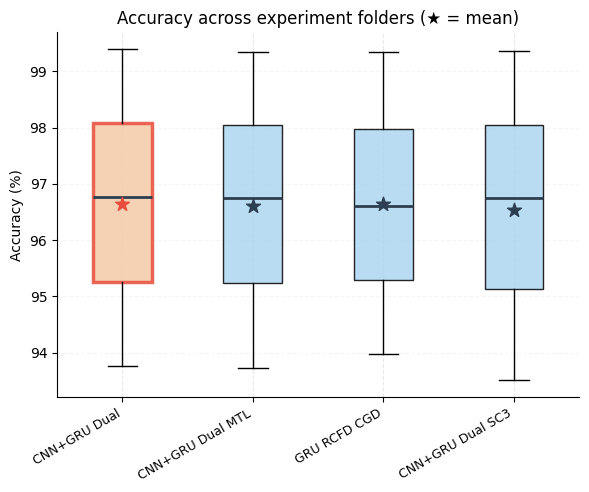
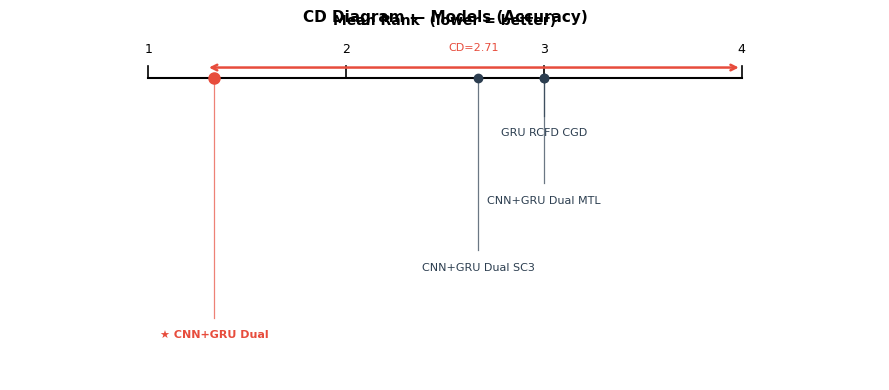
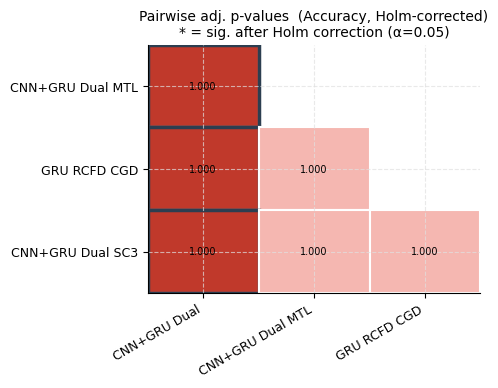

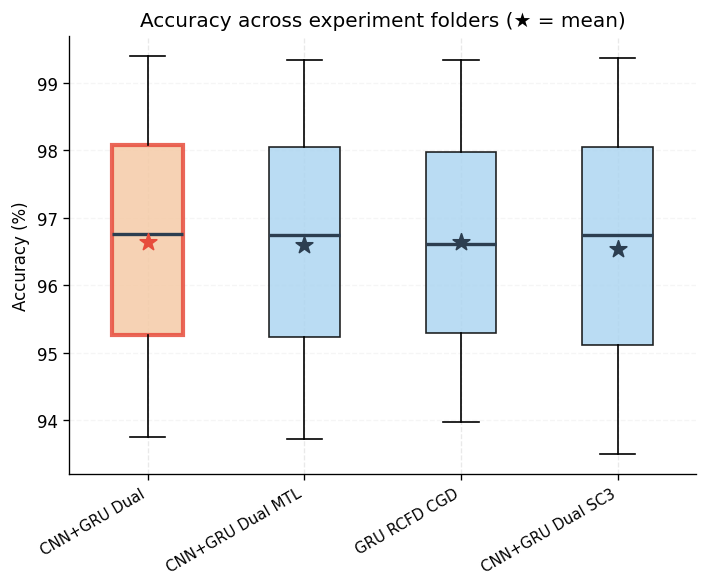

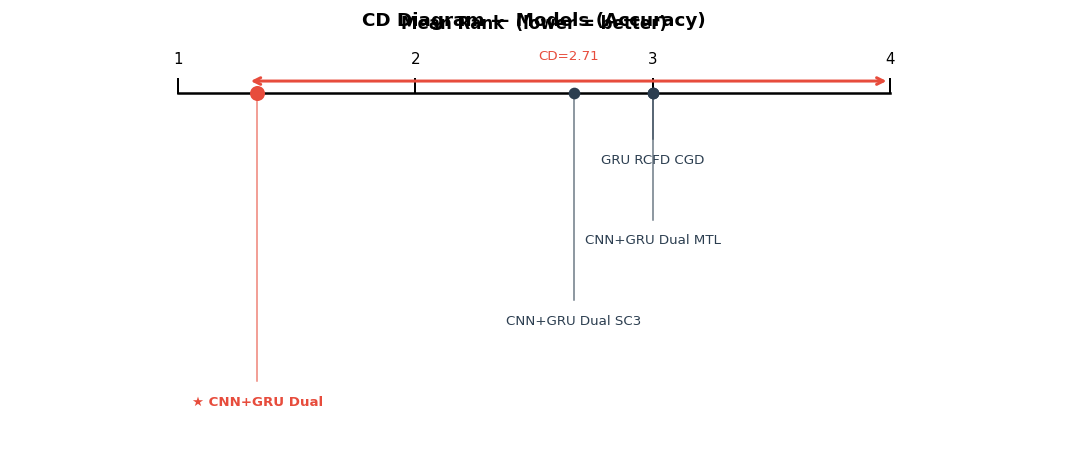

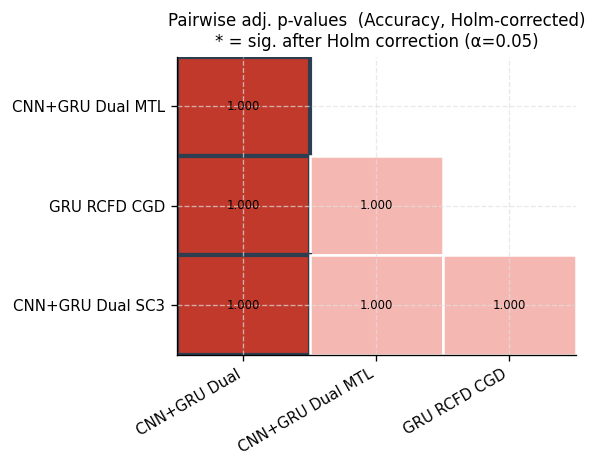

In [5]:
exp_data_3 = load_ablation_across_datasets(
    config.LAB_EXP_FOLDER, LAB_DATASETS,
    "ablation3_generalisability_performances.joblib",
    ABLATION3_CGD_FAMILY + ABLATION3_ATTN_FAMILY)

stats3a, figs3a, tt3a, _ = stat_comparison.run_comparison(
    exp_data_3, compare_axis="models", all_conditions=ABLATION3_CGD_FAMILY,
    condition_print_map=config.MODEL_PRINT_MAP,
    fixed={"curve_type": "ori_curve", "filter": None},
    baseline_key="cnn_gru_dual", metric=METRIC, alpha=ALPHA,
)
show_result(stats3a, figs3a, tt3a, title="Ablation 3: CGD family (base / MTL / RCFD / SupCon3)")


In [6]:
stats3b, figs3b, tt3b, _ = stat_comparison.run_comparison(
    exp_data_3, compare_axis="models", all_conditions=ABLATION3_ATTN_FAMILY,
    condition_print_map=config.MODEL_PRINT_MAP,
    fixed={"curve_type": "ori_curve", "filter": None},
    baseline_key="cnn_gru_dual_attn_recon", metric=METRIC, alpha=ALPHA,
)
show_result(stats3b, figs3b, tt3b, title="Ablation 3: AttnRecon family (base / MTL / RCFD / SupCon3)")


## Ablation 2 -- Curve Preprocessing (plain vs nc_subtract)

Phase-2-only: needs the 3 `POC_DDM_final` folders that have a matched `POC_DDM_final_nc_subtract` sibling (see `abl_ablation2_curve_preprocessing.sh` for how that set was determined -- re-check `get_exp_paths` if new nc_subtract runs are added). Two conditions per model (`plain`, `nc_subtract`), N=3 matched datasets -> real Friedman+Wilcoxon, not the McNemar fallback.

In [7]:
NC_MATCHED_DATASETS = [
    'D20260806_E00_C00_F4500KHz_U_DDM_01_06',
    'D20260807_E00_C00_F4500KHz_U_DDM_02_07',
    'D20260808_E00_C00_F4500KHz_U_DDM_03_01',
]
ABLATION2_MODELS = ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']


def load_ablation2_variant(dataset_names, tag, model_key, metric=METRIC):
    """One accuracy value per dataset for a single model + preprocessing variant."""
    preds_key = config.MODEL_KEY_MAP[model_key][0]
    values, y_true_all, y_pred_all = {}, {}, {}
    for name in dataset_names:
        path = (Path(config.FINAL_EXP_FOLDER) / name / "ablations"
                / f"ablation2_curve_preprocessing_{tag}_performances.joblib")
        if not path.exists():
            continue
        raw = joblib.load(path)
        res = raw.get(None, {})
        if preds_key not in res or "y_trues_" not in res:
            continue
        yt = np.concatenate(res["y_trues_"])
        yp = np.concatenate(res[preds_key])
        values[name] = stat_comparison._compute_metric(yt, yp, metric)
        y_true_all[name], y_pred_all[name] = yt, yp
    return values, y_true_all, y_pred_all


for model_key in ABLATION2_MODELS:
    plain_vals, _, _ = load_ablation2_variant(NC_MATCHED_DATASETS, 'plain', model_key)
    nc_vals, _, _ = load_ablation2_variant(NC_MATCHED_DATASETS, 'nc_subtract', model_key)
    matched = [d for d in NC_MATCHED_DATASETS if d in plain_vals and d in nc_vals]

    if len(matched) < 2:
        print(f'[{model_key}] fewer than 2 matched datasets with results ({len(matched)}) -- skipping.')
        continue

    matrix = np.array([[plain_vals[d], nc_vals[d]] for d in matched])
    stats2 = stat_comparison.run_friedman_posthoc(
        matrix, ['plain', 'nc_subtract'], ['Plain', 'NC-Subtract'],
        baseline_idx=0, alpha=ALPHA)
    figs2 = {
        'boxplot': stat_comparison.plot_accuracy_boxplot(
            matrix, ['Plain', 'NC-Subtract'], metric_name='Accuracy', baseline_idx=0),
    }
    if 'error' not in stats2:
        figs2['pvalue'] = stat_comparison.plot_pvalue_heatmap(
            stats2['adj_mat'], stats2['rej_mat'], ['Plain', 'NC-Subtract'],
            baseline_idx=0, alpha=ALPHA, metric_name='Accuracy')
    show_result(stats2, figs2, 'friedman',
               title=f'Ablation 2: {config.MODEL_PRINT_MAP.get(model_key, model_key)} -- Plain vs NC-Subtract')


[cnn_gru_dual] fewer than 2 matched datasets with results (0) -- skipping.
[cnn_gru_dual_attn_recon] fewer than 2 matched datasets with results (0) -- skipping.


## Optional: save a combined HTML report

Writes the same tabbed HTML format `08_statistical_comparison.py` produces, so it can be shared/reopened without re-running this notebook.

In [8]:
from html_utils import build_tabbed_html

SAVE_REPORT = False  # flip to True to write the file

if SAVE_REPORT:
    tabs = [
        ("ablation1", "Ablation 1: Models", stat_comparison.build_tab_content(stats1, figs1, test_type1, 'Accuracy', ALPHA)),
        ("ablation3_cgd", "Ablation 3: CGD family", stat_comparison.build_tab_content(stats3a, figs3a, tt3a, 'Accuracy', ALPHA)),
        ("ablation3_attn", "Ablation 3: AttnRecon family", stat_comparison.build_tab_content(stats3b, figs3b, tt3b, 'Accuracy', ALPHA)),
    ]
    out_dir = Path(config.LAB_EXP_FOLDER) / "ablations" / "stat_comparison"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "ablation_significance_report.html"
    build_tabbed_html("Ablation Significance Analysis", tabs, out_path)
    print(f'[SAVED] {out_path}')
